In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [3]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [4]:
# # Input Features
#     AT = Temperature
#     V = Vacuum
#     AP = Pressure
#     RH = Humidity

# # Output Features 
#     PE = Predicted Energy

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling Data

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Converting to tensors

In [8]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [9]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Define ANN Model

In [10]:
# Model Architecture
# input layer ==> 4 neurons
# 2 hidden layers ==> each of 6 neurons
# output layer ==> 1 neuron

In [11]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1],6),    #1st hidden layer
            nn.ReLU(),

            nn.Linear(6,6),    #2nd Hidden Layer
            nn.ReLU(),

            nn.Linear(6,1)    #Output Layer
        )

    def forward(self, x):
        return self.model(x)


# Backward Propagation
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### Training the model

In [12]:
best_val_loss = float("inf")
train_loss = []

epochs = 100

for epoch in range(epochs):
    model.train()

    running_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss

    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)


    # Validation 
    model.eval()

    running_val_loss = 0
    valid_losses = []
    
    with torch.no_grad() :
        for xb, yb in test_loader :
            optimizer.zero_grad()

            output = model(xb)
            val_loss = criterion(output, yb)

            running_val_loss += val_loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"For epoch {epoch+1}/{epochs}, training loss = {epoch_train_loss} and validation loss = {epoch_val_loss}")

    if best_val_loss > epoch_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

For epoch 1/100, training loss = 205444.578125 and validation loss = 203203.921875
For epoch 2/100, training loss = 197114.046875 and validation loss = 187226.046875
For epoch 3/100, training loss = 170309.453125 and validation loss = 147973.75
For epoch 4/100, training loss = 122502.9140625 and validation loss = 97601.03125
For epoch 5/100, training loss = 79677.40625 and validation loss = 64012.52734375
For epoch 6/100, training loss = 51413.02734375 and validation loss = 37585.1640625
For epoch 7/100, training loss = 28049.810546875 and validation loss = 19489.267578125
For epoch 8/100, training loss = 15430.828125 and validation loss = 11686.693359375
For epoch 9/100, training loss = 10051.638671875 and validation loss = 7990.595703125
For epoch 10/100, training loss = 7016.46826171875 and validation loss = 5587.37158203125
For epoch 11/100, training loss = 4978.26708984375 and validation loss = 3969.35400390625
For epoch 12/100, training loss = 3571.998779296875 and validation los

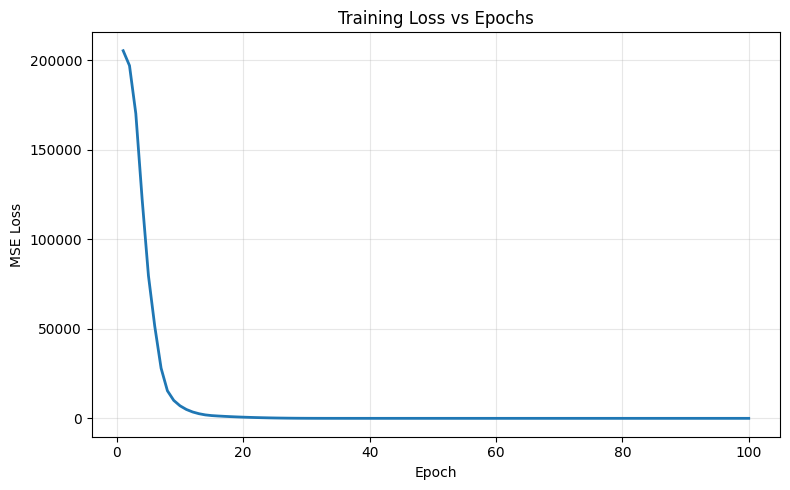

In [31]:
import matplotlib.pyplot as plt

# Convert tensor losses to float
losses = [loss.item() for loss in train_loss]

plt.figure(figsize=(8,5))

plt.plot(range(1, len(losses)+1), losses, linewidth=2)

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("images/training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

### Saving Best Model

In [13]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Evaluation

In [14]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print(f"Train MSE loss = {train_mse_loss} \nTest MSE loss = {test_mse_loss}")

from sklearn.metrics import r2_score
print(f"Training R2 score = {r2_score(y_train_tensor, train_preds)}")
print(f"Testing R2 score = {r2_score(y_test_tensor, test_preds)}")

Train MSE loss = 20.042646408081055 
Test MSE loss = 18.39311981201172
Training R2 score = 0.931483268737793
Testing R2 score = 0.9357208013534546


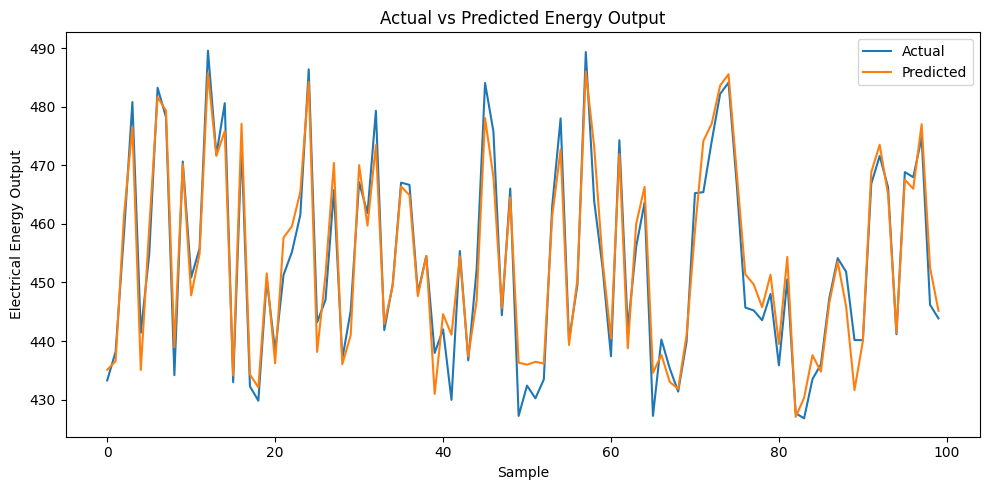

In [25]:
import matplotlib.pyplot as plt

actual = y_test_tensor.numpy().flatten()
predicted = test_preds.numpy().flatten()

plt.figure(figsize=(10,5))

plt.plot(actual[:100], label="Actual")
plt.plot(predicted[:100], label="Predicted")

plt.title("Actual vs Predicted Energy Output")
plt.xlabel("Sample")
plt.ylabel("Electrical Energy Output")

plt.legend()

plt.tight_layout()

plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

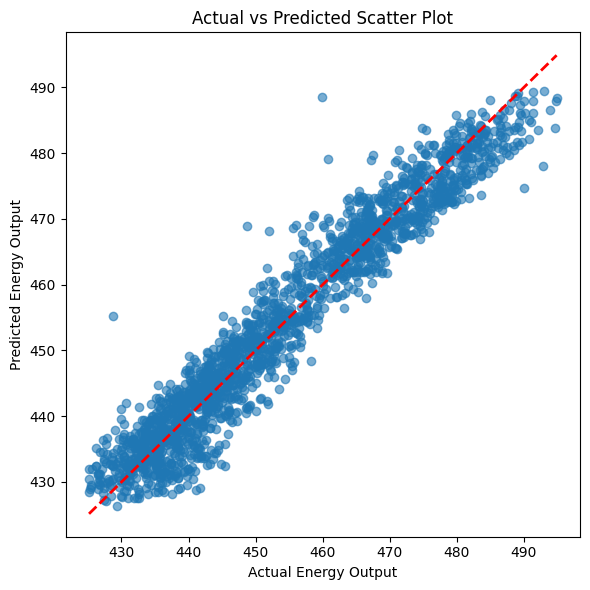

In [26]:
import matplotlib.pyplot as plt
import numpy as np

actual = y_test_tensor.numpy().flatten()
predicted = test_preds.numpy().flatten()

plt.figure(figsize=(6,6))

plt.scatter(actual, predicted, alpha=0.6)

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Energy Output")
plt.ylabel("Predicted Energy Output")

plt.title("Actual vs Predicted Scatter Plot")

plt.tight_layout()

plt.savefig("images/prediction_scatter.png", dpi=300, bbox_inches="tight")

plt.show()

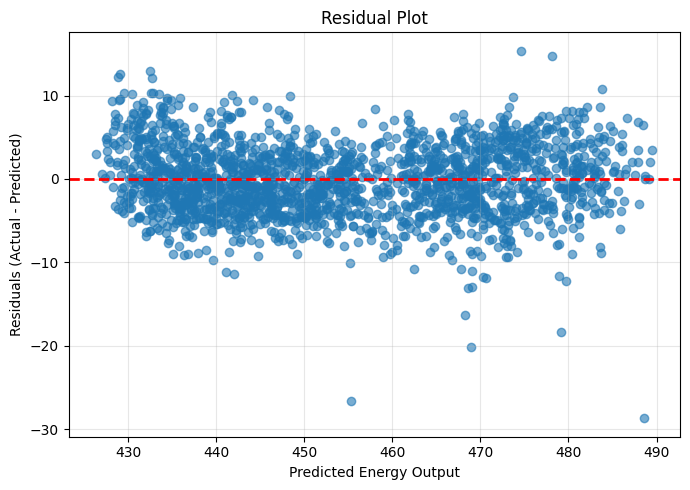

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to NumPy arrays
actual = y_test_tensor.detach().numpy().flatten()
predicted = test_preds.detach().numpy().flatten()

# Calculate residuals
residuals = actual - predicted

# Plot
plt.figure(figsize=(7,5))

plt.scatter(predicted, residuals, alpha=0.6)

# Horizontal reference line at zero residual
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title("Residual Plot")
plt.xlabel("Predicted Energy Output")
plt.ylabel("Residuals (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.tight_layout()

# Save for README
plt.savefig("images/residual_plot.png", dpi=300, bbox_inches="tight")

plt.show()